# **Basic Anomaly Detection on Hydrogen Trasport Network Testbed**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.metrics import recall_score, confusion_matrix, classification_report, auc, roc_curve
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope, MinCovDet
from pyod.models.knn import KNN
import seaborn as sns

# **1. Load Data**

In [10]:
df_down = pd.read_parquet("./Dataset_Hydrogen/normality_scenarios/normality_gest_down.parquet")
df_center = pd.read_parquet("./Dataset_Hydrogen/normality_scenarios/normality_gest_center.parquet")
df_up = pd.read_parquet("./Dataset_Hydrogen/normality_scenarios/normality_gest_up.parquet")


ps11_val = df_down['PS9'].iloc[0]
ps12_val = df_down['PS10'].iloc[0]

# Funzione per inserire colonne dopo una colonna specifica
def insert_after(df, col_name, new_cols_dict):
    cols = list(df.columns)
    idx = cols.index(col_name) + 1
    for k, v in reversed(new_cols_dict.items()):
        df.insert(loc=idx, column=k, value=v)
    return df

# Aggiungi PS11 e PS12 a df_center
df_center = insert_after(df_center, "PS10", {
    "PS11": ps11_val,
    "PS12": ps12_val
})

# Aggiungi PS11 e PS12 a df_up
df_up = insert_after(df_up, "PS10", {
    "PS11": ps11_val,
    "PS12": ps12_val
})

# Aggiungi MFS4 = 0.0 dopo MFS3
df_center = insert_after(df_center, "MFS3", {
    "MFS4": 0.0
})

df_up = insert_after(df_up, "MFS3", {
    "MFS4": 0.0
})

display(df_down)
display(df_center.iloc[:, :12])
display(df_up.iloc[:, :12])

,PS1,PS2,PS3,PS4,PS5,PS6,PS7,PS8,PS9,PS10,...,MFS3,MFS4,label_anomaly,Leak,CompressorFault,CompressorDelay,leak_G3,leak_G4,leak_G5,leak_G6
Timestamp,,,,,,,,,,,,,,,,,,,,,
0.0,3.732251,3.703099,3.392205,3.339121,0.1,0.740000,3.403099,3.740000,3.339121,2.339121,...,4.840802,21.935845,0,0,0,0,0,0,0,0
1.0,3.732251,3.703099,3.392205,3.339121,0.1,0.740000,3.403099,3.740000,3.339121,2.339121,...,4.840802,21.935845,0,0,0,0,0,0,0,0
2.0,3.732251,3.703099,3.392205,3.339121,0.1,0.740000,3.403099,3.740000,3.339121,2.339121,...,4.840802,21.935845,0,0,0,0,0,0,0,0
3.0,3.732251,3.703099,3.392205,3.339121,0.1,0.740000,3.403099,3.740000,3.339121,2.339121,...,4.840802,21.935845,0,0,0,0,0,0,0,0
4.0,3.729055,3.703085,3.392204,3.339121,0.1,0.730000,3.403085,3.730000,3.339121,2.339121,...,4.838638,21.935845,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995.0,6.686597,6.639338,6.118258,6.008059,0.1,0.294710,6.139488,6.694710,6.008059,5.008059,...,6.256224,33.755054,0,0,0,0,0,0,0,0
19996.0,6.686457,6.639203,6.118114,6.007919,0.1,0.294568,6.139343,6.694568,6.007919,5.007919,...,6.255852,33.754507,0,0,0,0,0,0,0,0
19997.0,6.686317,6.639069,6.117970,6.007778,0.1,0.294426,6.139199,6.694426,6.007778,5.007778,...,6.255481,33.753960,0,0,0,0,0,0,0,0


,PS1,PS2,PS3,PS4,PS5,PS6,PS7,PS8,PS9,PS10,PS11,PS12
Timestamp,,,,,,,,,,,,
0.0,3.715877,3.609410,3.266582,3.019574,0.740000,3.309410,3.740000,3.019574,3.096788,3.266582,3.339121,2.339121
1.0,3.715877,3.609410,3.266582,3.019574,0.740000,3.309410,3.740000,3.019574,3.096788,3.266582,3.339121,2.339121
2.0,3.715877,3.609410,3.266582,3.019574,0.740000,3.309410,3.740000,3.019574,3.096788,3.266582,3.339121,2.339121
3.0,3.715877,3.609410,3.266582,3.019574,0.740000,3.309410,3.740000,3.019574,3.096788,3.266582,3.339121,2.339121
4.0,3.714536,3.609406,3.266582,3.019574,0.730000,3.309406,3.730000,3.019574,3.096788,3.266582,3.339121,2.339121
...,...,...,...,...,...,...,...,...,...,...,...,...
19995.0,6.671394,6.520610,5.945677,5.493800,0.294710,6.020760,6.694710,5.493799,5.635776,5.945677,3.339121,2.339121
19996.0,6.671258,6.520497,5.945558,5.493691,0.294568,6.020637,6.694568,5.493691,5.635665,5.945558,3.339121,2.339121
19997.0,6.671123,6.520385,5.945439,5.493582,0.294426,6.020515,6.694426,5.493582,5.635553,5.945439,3.339121,2.339121


,PS1,PS2,PS3,PS4,PS5,PS6,PS7,PS8,PS9,PS10,PS11,PS12
Timestamp,,,,,,,,,,,,
0.0,3.712462,3.589103,3.262219,3.258601,0.740000,3.289103,3.740000,3.262623,3.259004,3.262219,3.339121,2.339121
1.0,3.712462,3.589103,3.262219,3.258601,0.740000,3.289103,3.740000,3.262623,3.259004,3.262219,3.339121,2.339121
2.0,3.712462,3.589103,3.262219,3.258601,0.740000,3.289103,3.740000,3.262623,3.259004,3.262219,3.339121,2.339121
3.0,3.712462,3.589103,3.262219,3.258601,0.740000,3.289103,3.740000,3.262623,3.259004,3.262219,3.339121,2.339121
4.0,3.711224,3.589100,3.262219,3.258601,0.730000,3.289100,3.730000,3.262622,3.259004,3.262219,3.339121,2.339121
...,...,...,...,...,...,...,...,...,...,...,...,...
19995.0,6.667753,6.492079,5.945523,5.939211,0.294710,5.992229,6.694710,5.946162,5.939928,5.945523,3.339121,2.339121
19996.0,6.667619,6.491970,5.945406,5.939094,0.294568,5.992110,6.694568,5.946045,5.939811,5.945406,3.339121,2.339121
19997.0,6.667484,6.491861,5.945290,5.938977,0.294426,5.991991,6.694426,5.945928,5.939695,5.945290,3.339121,2.339121


In [11]:
def load_all_parquets(folder_path):
    dfs = {}
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.endswith(".parquet"):
                full_path = os.path.join(root, file)
                df = pd.read_parquet(full_path)
                dfs[file] = df
    return dfs

# Percorsi
base_path = "./Dataset_Hydrogen/anomalous_scenarios/"
down_path = os.path.join(base_path, "anom_gestdown")
center_path = os.path.join(base_path, "anom_gestcent")
up_path = os.path.join(base_path, "anom_gestup")

# Caricamento
anom_gestdown_dfs = load_all_parquets(down_path)
anom_gestcenter_dfs = load_all_parquets(center_path)
anom_gestup_dfs = load_all_parquets(up_path)

# Funzione per aggiornare un DataFrame
def update_anomaly_df(ref_df, target_df):
    # Prendi valori costanti da PS9, PS10 nel file di riferimento
    ps11_val = ref_df['PS9'].iloc[0]
    ps12_val = ref_df['PS10'].iloc[0]

    # Costruisci colonne da aggiungere
    ps11_col = pd.Series(ps11_val, index=target_df.index)
    ps12_col = pd.Series(ps12_val, index=target_df.index)
    mfs4_col = pd.Series(0.0, index=target_df.index)

    # Inserisci PS11, PS12 dopo PS10
    ps10_idx = target_df.columns.get_loc('PS10')
    target_df.insert(ps10_idx + 1, 'PS11', ps11_col)
    target_df.insert(ps10_idx + 2, 'PS12', ps12_col)

    # Inserisci MFS4 dopo MFS3
    mfs3_idx = target_df.columns.get_loc('MFS3')
    target_df.insert(mfs3_idx + 1, 'MFS4', mfs4_col)

    return target_df

# Applicazione su tutti i file
for filename, df_down in anom_gestdown_dfs.items():
    if filename in anom_gestcenter_dfs:
        anom_gestcenter_dfs[filename] = update_anomaly_df(df_down, anom_gestcenter_dfs[filename])
    if filename in anom_gestup_dfs:
        anom_gestup_dfs[filename] = update_anomaly_df(df_down, anom_gestup_dfs[filename])
first_key = list(anom_gestcenter_dfs.keys())[2]
display(anom_gestcenter_dfs[first_key].iloc[:, :12])

,PS1,PS2,PS3,PS4,PS5,PS6,PS7,PS8,PS9,PS10,PS11,PS12
Timestamp,,,,,,,,,,,,
0.0,3.720959,3.623257,3.285089,3.066244,0.740508,3.324395,3.741443,3.066513,3.133241,3.285430,3.36615,2.365341
1.0,3.719821,3.624590,3.285368,3.065667,0.740440,3.324262,3.740677,3.065583,3.132792,3.285268,3.36615,2.365341
2.0,3.721167,3.624917,3.285904,3.065337,0.739805,3.323591,3.740805,3.065038,3.133766,3.286079,3.36615,2.365341
3.0,3.721774,3.624738,3.286251,3.065393,0.739655,3.322843,3.738922,3.063953,3.133901,3.285638,3.36615,2.365341
4.0,3.718985,3.623505,3.285402,3.066965,0.730412,3.324260,3.729027,3.066373,3.133117,3.285461,3.36615,2.365341
...,...,...,...,...,...,...,...,...,...,...,...,...
19995.0,6.633433,6.506462,5.940126,5.533846,0.296811,6.007032,6.694666,5.533631,5.659581,5.939038,3.36615,2.365341
19996.0,6.632919,6.505668,5.939482,5.535022,0.293428,6.006835,6.694354,5.533575,5.660148,5.941171,3.36615,2.365341
19997.0,6.632711,6.505859,5.939847,5.534344,0.293982,6.007361,6.693301,5.534534,5.660882,5.938058,3.36615,2.365341


# **2. Normalization and Partitioning of Data into Training, Validation, and Test Sets**

In [ ]:
PS_cols = [f"PS{i}" for i in range(1, 13)]
MFS_cols = [f"MFS{i}" for i in range(1, 5)]
label_col = "label_anomaly"

# === 2. COSTRUZIONE TRAIN SET ===

train_parts = []
for df in [df_down, df_center, df_up]:
    cols_present = [col for col in PS_cols + MFS_cols if col in df.columns]
    df_subset = df[cols_present + [label_col]].copy()
    
    # Aggiungi colonne mancanti come NaN
    for col in PS_cols + MFS_cols:
        if col not in df_subset.columns:
            df_subset[col] = pd.NA
            
    df_subset = df_subset[PS_cols + MFS_cols + [label_col]]
    train_parts.append(df_subset)

df_train = pd.concat(train_parts, ignore_index=True)
df_train = shuffle(df_train, random_state=42).reset_index(drop=True)

# === 3. COSTRUZIONE TEST SET ===

def create_test_set(dict_dfs, ps_cols, mfs_cols, label_col):
    test_dfs = []
    for df in dict_dfs.values():
        cols_present = [col for col in ps_cols + mfs_cols if col in df.columns]
        df_subset = df[cols_present + [label_col]].copy()
        
        for col in ps_cols + mfs_cols:
            if col not in df_subset.columns:
                df_subset[col] = pd.NA
                
        df_subset = df_subset[ps_cols + mfs_cols + [label_col]]
        test_dfs.append(df_subset)
    
    return pd.concat(test_dfs, ignore_index=True)

df_test_down = create_test_set(anom_gestdown_dfs, PS_cols, MFS_cols, label_col)
df_test_center = create_test_set(anom_gestcenter_dfs, PS_cols, MFS_cols, label_col)
df_test_up = create_test_set(anom_gestup_dfs, PS_cols, MFS_cols, label_col)

df_test = pd.concat([df_test_down, df_test_center, df_test_up], ignore_index=True)

# === 4. SCALING SEPARATO PS / MFS ===

scaler_ps = StandardScaler()
scaler_mfs = StandardScaler()

# Fit solo su training
X_train_ps = df_train[PS_cols].astype(float)
X_train_mfs = df_train[MFS_cols].astype(float)

X_train_ps_scaled = scaler_ps.fit_transform(X_train_ps)
X_train_mfs_scaled = scaler_mfs.fit_transform(X_train_mfs)

# Trasforma anche il test
X_test_ps = df_test[PS_cols].astype(float)
X_test_mfs = df_test[MFS_cols].astype(float)

X_test_ps_scaled = scaler_ps.transform(X_test_ps)
X_test_mfs_scaled = scaler_mfs.transform(X_test_mfs)

# === 5. CONCATENAZIONE FINALE ===

X_train = np.hstack([X_train_ps_scaled, X_train_mfs_scaled])
X_test = np.hstack([X_test_ps_scaled, X_test_mfs_scaled])

y_train = df_train[label_col].astype(int).values
y_test = df_test[label_col].astype(int).values

# === 6. Verifica shapes ===
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:", np.bincount(y_train))
print("y_test distribution:", np.bincount(y_test))

X_train shape: (60000, 16)
X_test shape: (2040000, 16)
y_train distribution: [40025 19975]
y_test distribution: [ 330144 1709856]


# **3. Train Basic Models and Optimize Hyperparameters with GridSearch based on Specificity**
Plot AUC-ROC

nu=0.01, gamma=scale, kernel=poly → Recall (classe 0) su train: 0.9985
nu=0.01, gamma=scale, kernel=sigmoid → Recall (classe 0) su train: 0.9985
nu=0.01, gamma=scale, kernel=linear → Recall (classe 0) su train: 0.9985
nu=0.01, gamma=scale, kernel=rbf → Recall (classe 0) su train: 0.9923
nu=0.01, gamma=auto, kernel=poly → Recall (classe 0) su train: 0.9985
nu=0.01, gamma=auto, kernel=sigmoid → Recall (classe 0) su train: 0.0000
nu=0.01, gamma=auto, kernel=linear → Recall (classe 0) su train: 0.9985
nu=0.01, gamma=auto, kernel=rbf → Recall (classe 0) su train: 0.9923
nu=0.01, gamma=0.01, kernel=poly → Recall (classe 0) su train: 0.9985
nu=0.01, gamma=0.01, kernel=sigmoid → Recall (classe 0) su train: 0.9985
nu=0.01, gamma=0.01, kernel=linear → Recall (classe 0) su train: 0.9985
nu=0.01, gamma=0.01, kernel=rbf → Recall (classe 0) su train: 0.9923
nu=0.01, gamma=0.1, kernel=poly → Recall (classe 0) su train: 0.9985
nu=0.01, gamma=0.1, kernel=sigmoid → Recall (classe 0) su train: 0.0000
nu=

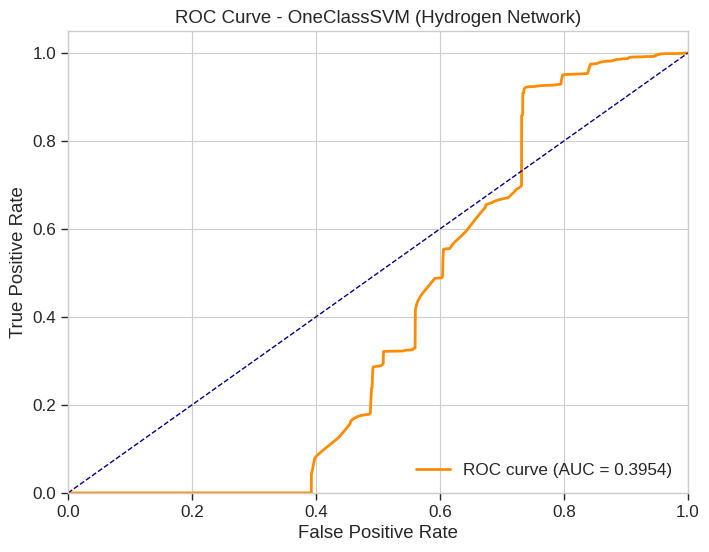

In [13]:
X_train = df_train.drop(columns=['label_anomaly'])
y_train = df_train['label_anomaly']  # tutti 0

X_test = df_test.drop(columns=['label_anomaly'])
y_test = df_test['label_anomaly']    # 0 e 1

# === 2. Grid search per ottimizzare la specificity (recall classe 0) ===

nus = [0.01, 0.05, 0.1, 0.15, 0.2]
gammas = ['scale', 'auto', 0.01, 0.1, 1]
kernels = ['poly', 'sigmoid', 'linear', 'rbf']

best_recall_0 = 0
best_model = None
best_params = {}

for nu in nus:
    for gamma in gammas:
        for kernel in kernels:
            model = OneClassSVM(kernel=kernel, nu=nu, gamma=gamma)
            model.fit(X_train)

            # Previsione sul training (solo normali)
            y_pred_train = model.predict(X_train)
            y_pred_binary_train = np.where(y_pred_train == -1, 1, 0)  # 1=anomaly, 0=normal

            recall_0 = recall_score(y_train, y_pred_binary_train, pos_label=0)

            print(f"nu={nu}, gamma={gamma}, kernel={kernel} → Recall (classe 0) su train: {recall_0:.4f}")

            if recall_0 > best_recall_0:
                best_recall_0 = recall_0
                best_model = model
                best_params = {"nu": nu, "gamma": gamma, "kernel": kernel}

# === 3. Risultati finali ===

print(f"\nBest model: nu={best_params['nu']}, gamma={best_params['gamma']}, kernel={best_params['kernel']} → recall_0_train={best_recall_0:.4f}")

# === 4. Valutazione sul test set ===

y_pred_test = best_model.predict(X_test)
y_pred_binary_test = np.where(y_pred_test == -1, 1, 0)

recall_0_test = recall_score(y_test, y_pred_binary_test, pos_label=0)  # Specificità
recall_1_test = recall_score(y_test, y_pred_binary_test, pos_label=1)  # Sensitività

print(f"\nRecall (classe 0 - normali) sul test set: {recall_0_test:.4f}")
print(f"Recall (classe 1 - anomalie) sul test set: {recall_1_test:.4f}")

print("\nConfusion Matrix (test):")
print(confusion_matrix(y_test, y_pred_binary_test))

print("\nClassification Report (test):")
print(classification_report(y_test, y_pred_binary_test, digits=4))

# === 5. ROC e AUC ===

# Decision function (score: più alto = più normale)
scores = best_model.decision_function(X_test)

# ROC: la classe positiva è l’anomalia (1), ma mettiamo pos_label=0 per specificità
fpr, tpr, thresholds = roc_curve(y_test, scores, pos_label=0)

roc_auc = auc(fpr, tpr)
roc_data = np.column_stack((fpr, tpr, thresholds))

np.savetxt("roc_data_oneclass_withMFS.txt", roc_data, fmt='%.6f', delimiter='\t', 
           header="FPR\tTPR\tThreshold", comments='')

# === 6. Plot ROC ===

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - OneClassSVM (Hydrogen Network)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

contamination=0.01, max_samples=0.5, n_estimators=50 -> recall normal (train): 0.9885
contamination=0.01, max_samples=0.5, n_estimators=100 -> recall normal (train): 0.9883
contamination=0.01, max_samples=0.5, n_estimators=200 -> recall normal (train): 0.9884
contamination=0.01, max_samples=0.7, n_estimators=50 -> recall normal (train): 0.9884
contamination=0.01, max_samples=0.7, n_estimators=100 -> recall normal (train): 0.9886
contamination=0.01, max_samples=0.7, n_estimators=200 -> recall normal (train): 0.9885
contamination=0.01, max_samples=1.0, n_estimators=50 -> recall normal (train): 0.9882
contamination=0.01, max_samples=1.0, n_estimators=100 -> recall normal (train): 0.9885
contamination=0.01, max_samples=1.0, n_estimators=200 -> recall normal (train): 0.9884
contamination=0.05, max_samples=0.5, n_estimators=50 -> recall normal (train): 0.9505
contamination=0.05, max_samples=0.5, n_estimators=100 -> recall normal (train): 0.9596
contamination=0.05, max_samples=0.5, n_estimato

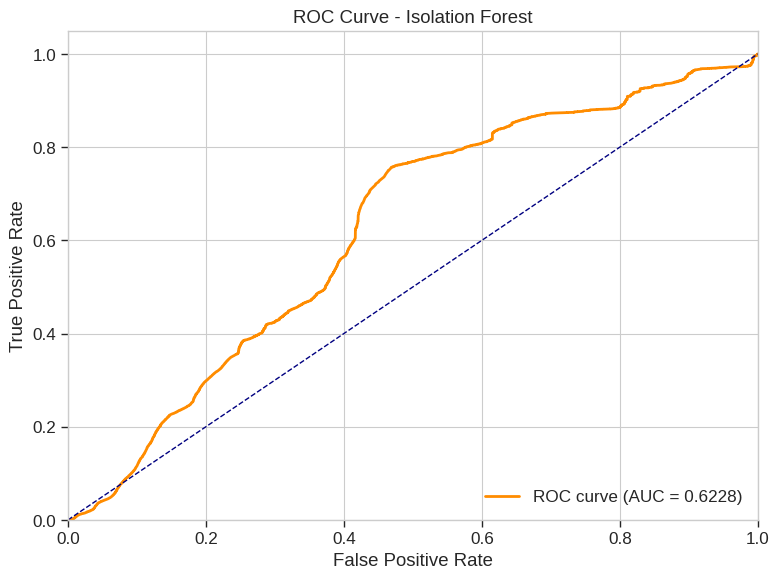

In [14]:
# Parametri da testare
contamination_values = [0.01, 0.05, 0.1, 0.15, 0.2]
max_samples_values = [0.5, 0.7, 1.0]
n_estimators_values = [50, 100, 200]

best_recall_0 = 0
best_params = None
best_model = None

for contamination in contamination_values:
    for max_samples in max_samples_values:
        for n_estimators in n_estimators_values:
            model = IsolationForest(
                contamination=contamination,
                max_samples=max_samples,
                n_estimators=n_estimators,
                random_state=42
            )
            model.fit(X_train)

            y_pred_train = model.predict(X_train)
            y_pred_binary_train = np.where(y_pred_train == -1, 1, 0)  # -1 = anomaly, 1 = normal

            recall_0 = recall_score(y_train, y_pred_binary_train, pos_label=0)

            print(f"contamination={contamination}, max_samples={max_samples}, "
                  f"n_estimators={n_estimators} -> recall normal (train): {recall_0:.4f}")

            if recall_0 > best_recall_0:
                best_recall_0 = recall_0
                best_params = (contamination, max_samples, n_estimators)
                best_model = model

print(f"\nBest params found: contamination={best_params[0]}, max_samples={best_params[1]}, "
      f"n_estimators={best_params[2]}, recall normal (train)={best_recall_0:.4f}")

# --- Valutazione sul test set ---
y_pred_test = best_model.predict(X_test)
y_pred_binary_test = np.where(y_pred_test == -1, 1, 0)

recall_0_test = recall_score(y_test, y_pred_binary_test, pos_label=0)  # Specificità
sensitivity_test = recall_score(y_test, y_pred_binary_test, pos_label=1)  # Sensibilità

print(f"\n[TEST SET]")
print(f"Recall (normali, classe 0): {recall_0_test:.4f}")
print(f"Sensitivity (anomalie, classe 1): {sensitivity_test:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_binary_test))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_binary_test, digits=4))

# --- ROC Curve ---
scores = best_model.decision_function(X_test)  # Score positivo = più normale
fpr, tpr, thresholds = roc_curve(y_test, scores, pos_label=0)

roc_data = np.column_stack((fpr, tpr, thresholds))
np.savetxt("roc_data_isolationf_withMFS.txt", roc_data, fmt='%.6f', delimiter='\t',
           header="FPR\tTPR\tThreshold", comments='')

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Isolation Forest')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


LOF params={'n_neighbors': 10, 'contamination': 0.01} -> recall normal (train): 0.9902
LOF params={'n_neighbors': 10, 'contamination': 0.05} -> recall normal (train): 0.9568
LOF params={'n_neighbors': 10, 'contamination': 0.1} -> recall normal (train): 0.9246
LOF params={'n_neighbors': 10, 'contamination': 0.15} -> recall normal (train): 0.8778
LOF params={'n_neighbors': 10, 'contamination': 0.2} -> recall normal (train): 0.8212
LOF params={'n_neighbors': 20, 'contamination': 0.01} -> recall normal (train): 0.9906
LOF params={'n_neighbors': 20, 'contamination': 0.05} -> recall normal (train): 0.9581
LOF params={'n_neighbors': 20, 'contamination': 0.1} -> recall normal (train): 0.9093
LOF params={'n_neighbors': 20, 'contamination': 0.15} -> recall normal (train): 0.8633
LOF params={'n_neighbors': 20, 'contamination': 0.2} -> recall normal (train): 0.8094
LOF params={'n_neighbors': 30, 'contamination': 0.01} -> recall normal (train): 0.9921
LOF params={'n_neighbors': 30, 'contamination':

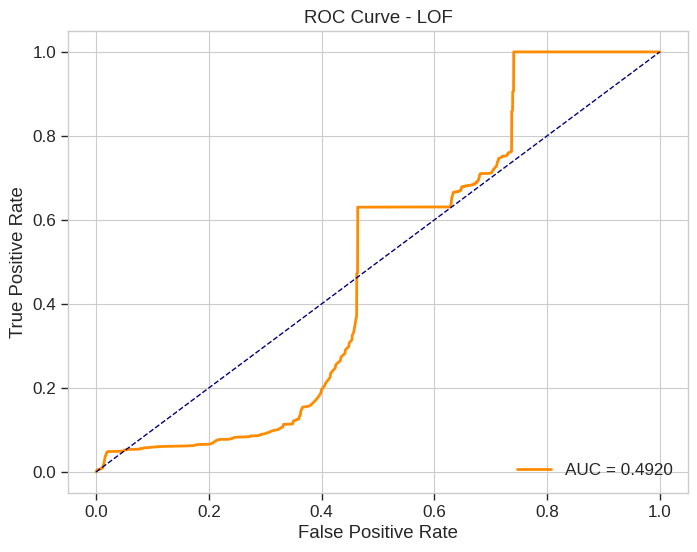

/home/andrea/miniconda3/envs/quantum_ml/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-326.103951537057640 > -326.961136639641722). You may want to try with a higher value of support_fraction (current value: 0.503).
  warnings.warn(
/home/andrea/miniconda3/envs/quantum_ml/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-334.207979967538165 > -334.285084361150155). You may want to try with a higher value of support_fraction (current value: 0.503).
  warnings.warn(
/home/andrea/miniconda3/envs/quantum_ml/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-328.156966471301587 > -329.019558684186336). You may want to try with

EllipticEnvelope params={'contamination': 0.01} -> recall normal (train): 0.9905


/home/andrea/miniconda3/envs/quantum_ml/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-326.103951537057640 > -326.961136639641722). You may want to try with a higher value of support_fraction (current value: 0.503).
  warnings.warn(
/home/andrea/miniconda3/envs/quantum_ml/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-334.207979967538165 > -334.285084361150155). You may want to try with a higher value of support_fraction (current value: 0.503).
  warnings.warn(
/home/andrea/miniconda3/envs/quantum_ml/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-328.156966471301587 > -329.019558684186336). You may want to try with

EllipticEnvelope params={'contamination': 0.05} -> recall normal (train): 0.9607


/home/andrea/miniconda3/envs/quantum_ml/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-326.103951537057640 > -326.961136639641722). You may want to try with a higher value of support_fraction (current value: 0.503).
  warnings.warn(
/home/andrea/miniconda3/envs/quantum_ml/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-334.207979967538165 > -334.285084361150155). You may want to try with a higher value of support_fraction (current value: 0.503).
  warnings.warn(
/home/andrea/miniconda3/envs/quantum_ml/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-328.156966471301587 > -329.019558684186336). You may want to try with

EllipticEnvelope params={'contamination': 0.1} -> recall normal (train): 0.9042


/home/andrea/miniconda3/envs/quantum_ml/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-326.103951537057640 > -326.961136639641722). You may want to try with a higher value of support_fraction (current value: 0.503).
  warnings.warn(
/home/andrea/miniconda3/envs/quantum_ml/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-334.207979967538165 > -334.285084361150155). You may want to try with a higher value of support_fraction (current value: 0.503).
  warnings.warn(
/home/andrea/miniconda3/envs/quantum_ml/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-328.156966471301587 > -329.019558684186336). You may want to try with

EllipticEnvelope params={'contamination': 0.15} -> recall normal (train): 0.8465


/home/andrea/miniconda3/envs/quantum_ml/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-326.103951537057640 > -326.961136639641722). You may want to try with a higher value of support_fraction (current value: 0.503).
  warnings.warn(
/home/andrea/miniconda3/envs/quantum_ml/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-334.207979967538165 > -334.285084361150155). You may want to try with a higher value of support_fraction (current value: 0.503).
  warnings.warn(
/home/andrea/miniconda3/envs/quantum_ml/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-328.156966471301587 > -329.019558684186336). You may want to try with

EllipticEnvelope params={'contamination': 0.2} -> recall normal (train): 0.8303

Best params for EllipticEnvelope: {'contamination': 0.01}, recall normal (train)=0.9905

Test set results for EllipticEnvelope:
Recall normal (classe 0): 0.6392
Sensitivity anomalie (classe 1): 0.7837
Confusion Matrix:
[[ 211016  119128]
 [ 369907 1339949]]

Classification Report:
              precision    recall  f1-score   support

           0     0.3632    0.6392    0.4632    330144
           1     0.9184    0.7837    0.8457   1709856

    accuracy                         0.7603   2040000
   macro avg     0.6408    0.7114    0.6545   2040000
weighted avg     0.8285    0.7603    0.7838   2040000



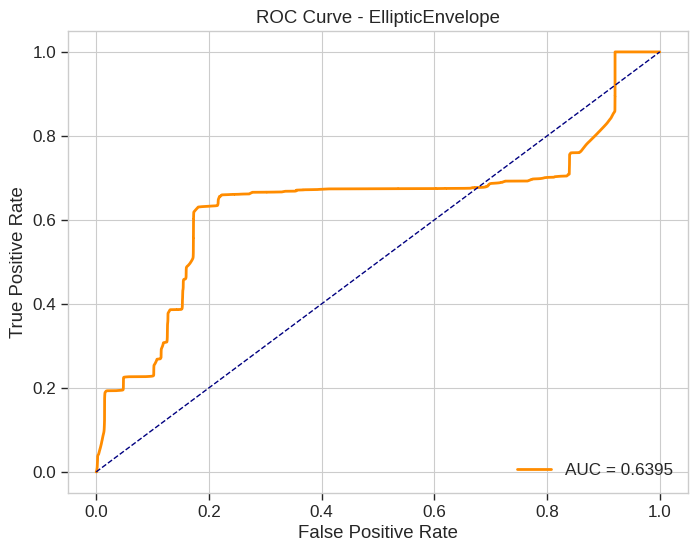

/home/andrea/miniconda3/envs/quantum_ml/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-284.502823524665928 > -284.798946401451417). You may want to try with a higher value of support_fraction (current value: 0.700).
  warnings.warn(
/home/andrea/miniconda3/envs/quantum_ml/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-282.949157170553633 > -283.056744620257007). You may want to try with a higher value of support_fraction (current value: 0.700).
  warnings.warn(
/home/andrea/miniconda3/envs/quantum_ml/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-282.839301574811429 > -283.196853565896276). You may want to try with

MCD params={'support_fraction': 0.7, 'contamination': 0.01} -> recall normal (train): 0.9936


/home/andrea/miniconda3/envs/quantum_ml/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-284.502823524665928 > -284.798946401451417). You may want to try with a higher value of support_fraction (current value: 0.700).
  warnings.warn(
/home/andrea/miniconda3/envs/quantum_ml/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-282.949157170553633 > -283.056744620257007). You may want to try with a higher value of support_fraction (current value: 0.700).
  warnings.warn(
/home/andrea/miniconda3/envs/quantum_ml/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-282.839301574811429 > -283.196853565896276). You may want to try with

MCD params={'support_fraction': 0.7, 'contamination': 0.05} -> recall normal (train): 0.9587


/home/andrea/miniconda3/envs/quantum_ml/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-284.502823524665928 > -284.798946401451417). You may want to try with a higher value of support_fraction (current value: 0.700).
  warnings.warn(
/home/andrea/miniconda3/envs/quantum_ml/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-282.949157170553633 > -283.056744620257007). You may want to try with a higher value of support_fraction (current value: 0.700).
  warnings.warn(
/home/andrea/miniconda3/envs/quantum_ml/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-282.839301574811429 > -283.196853565896276). You may want to try with

MCD params={'support_fraction': 0.7, 'contamination': 0.1} -> recall normal (train): 0.9043


/home/andrea/miniconda3/envs/quantum_ml/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-284.502823524665928 > -284.798946401451417). You may want to try with a higher value of support_fraction (current value: 0.700).
  warnings.warn(
/home/andrea/miniconda3/envs/quantum_ml/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-282.949157170553633 > -283.056744620257007). You may want to try with a higher value of support_fraction (current value: 0.700).
  warnings.warn(
/home/andrea/miniconda3/envs/quantum_ml/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-282.839301574811429 > -283.196853565896276). You may want to try with

MCD params={'support_fraction': 0.7, 'contamination': 0.15} -> recall normal (train): 0.8553


/home/andrea/miniconda3/envs/quantum_ml/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-284.502823524665928 > -284.798946401451417). You may want to try with a higher value of support_fraction (current value: 0.700).
  warnings.warn(
/home/andrea/miniconda3/envs/quantum_ml/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-282.949157170553633 > -283.056744620257007). You may want to try with a higher value of support_fraction (current value: 0.700).
  warnings.warn(
/home/andrea/miniconda3/envs/quantum_ml/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-282.839301574811429 > -283.196853565896276). You may want to try with

MCD params={'support_fraction': 0.7, 'contamination': 0.2} -> recall normal (train): 0.8181

Best params for MCD: {'support_fraction': 0.7, 'contamination': 0.01}, recall normal (train)=0.9936

Test set results for MCD:
Recall normal (classe 0): 1.0000
Sensitivity anomalie (classe 1): 0.0119
Confusion Matrix:
[[ 330144       0]
 [1689456   20400]]

Classification Report:
              precision    recall  f1-score   support

           0     0.1635    1.0000    0.2810    330144
           1     1.0000    0.0119    0.0236   1709856

    accuracy                         0.1718   2040000
   macro avg     0.5817    0.5060    0.1523   2040000
weighted avg     0.8646    0.1718    0.0652   2040000



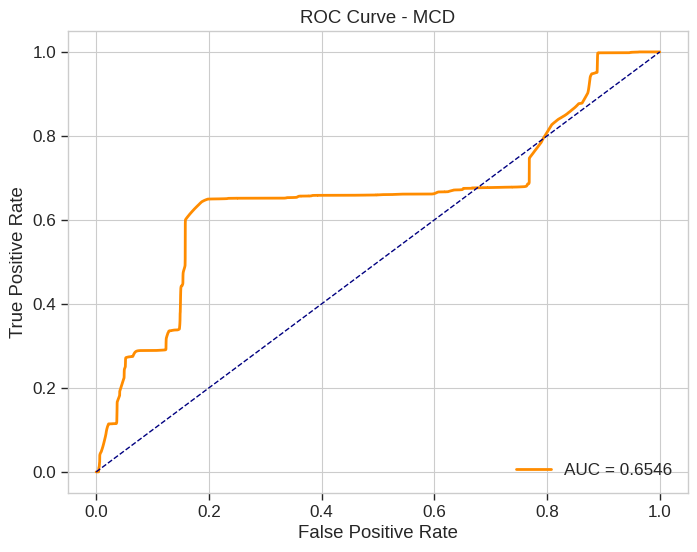

kNN params={'n_neighbors': 10, 'contamination': 0.01} -> recall normal (train): 0.9880
kNN params={'n_neighbors': 10, 'contamination': 0.05} -> recall normal (train): 0.9708
kNN params={'n_neighbors': 10, 'contamination': 0.1} -> recall normal (train): 0.9377
kNN params={'n_neighbors': 10, 'contamination': 0.15} -> recall normal (train): 0.8957
kNN params={'n_neighbors': 10, 'contamination': 0.2} -> recall normal (train): 0.8482
kNN params={'n_neighbors': 20, 'contamination': 0.01} -> recall normal (train): 0.9879
kNN params={'n_neighbors': 20, 'contamination': 0.05} -> recall normal (train): 0.9699
kNN params={'n_neighbors': 20, 'contamination': 0.1} -> recall normal (train): 0.9368
kNN params={'n_neighbors': 20, 'contamination': 0.15} -> recall normal (train): 0.8969
kNN params={'n_neighbors': 20, 'contamination': 0.2} -> recall normal (train): 0.8475
kNN params={'n_neighbors': 30, 'contamination': 0.01} -> recall normal (train): 0.9878
kNN params={'n_neighbors': 30, 'contamination':

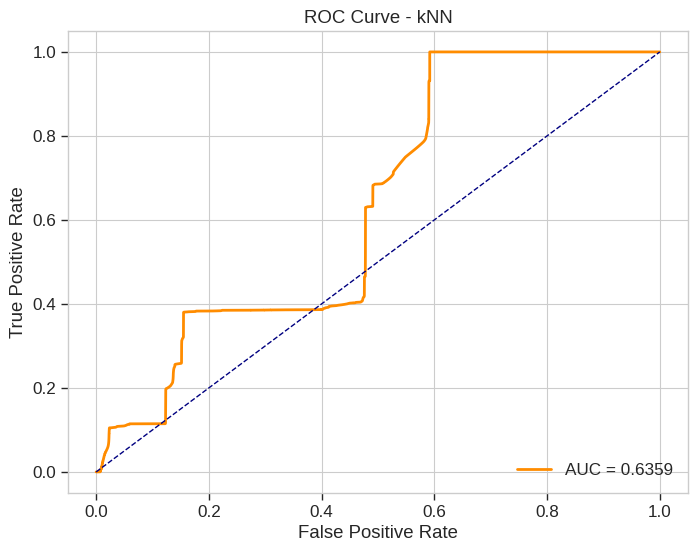

In [15]:
X_train = np.asarray(X_train)
X_test = np.asarray(X_test)
y_train = np.asarray(y_train)
y_test = np.asarray(y_test)

def evaluate_model(name, param_grid):
    best_recall_0 = 0
    best_params = None
    best_model = None
    
    for params in param_grid:
        if name == "LOF":
            model = LocalOutlierFactor(
                n_neighbors=params["n_neighbors"],
                contamination=params["contamination"],
                novelty=True
            )
            model.fit(X_train)
            y_pred_train = model.predict(X_train)
            scores = model.decision_function(X_test)
            
        
        elif name == "EllipticEnvelope":
            model = EllipticEnvelope(
                contamination=params["contamination"],
                random_state=42
            )
            model.fit(X_train)
            y_pred_train = model.predict(X_train)
            scores = model.decision_function(X_test)
            
        elif name == "MCD":
            model = MinCovDet(
                support_fraction=params["support_fraction"],
                random_state=42
            )
            model.fit(X_train)
            mahal_dist = model.mahalanobis(X_train)
            threshold = np.percentile(mahal_dist, (1 - params["contamination"]) * 100)
            y_pred_train = (mahal_dist > threshold).astype(int)
            y_pred_train = np.where(y_pred_train == 1, 1, 0)  # 1=anomaly, 0=normal
            scores = -model.mahalanobis(X_test)  # inverti per ROC
            
        elif name == "kNN":
            model = KNN(
                n_neighbors=params["n_neighbors"],
                contamination=params["contamination"]
            )
            model.fit(X_train)
            y_pred_train = model.labels_
            scores = -model.decision_scores_  # inverti per ROC (score alto = normalità)

        # Uniforma predizione: 1=anomaly, 0=normal
        if name not in ["MCD", "kNN"]:
            y_pred_binary_train = np.where(y_pred_train == -1, 1, 0)
        else:
            y_pred_binary_train = y_pred_train

        recall_0 = recall_score(y_train, y_pred_binary_train, pos_label=0)

        print(f"{name} params={params} -> recall normal (train): {recall_0:.4f}")

        if recall_0 > best_recall_0:
            best_recall_0 = recall_0
            best_params = params
            best_model = model

    print(f"\nBest params for {name}: {best_params}, recall normal (train)={best_recall_0:.4f}")

    # Test set evaluation
    if name == "LOF":
        y_pred_test = best_model.predict(X_test)
        scores = best_model.decision_function(X_test)
    elif name == "MCD":
        mahal_dist = best_model.mahalanobis(X_test)
        threshold = np.percentile(mahal_dist, (1 - best_params["contamination"]) * 100)
        y_pred_test = (mahal_dist > threshold).astype(int)
        scores = -mahal_dist
    elif name == "kNN":
        y_pred_test = best_model.predict(X_test)
        scores = -best_model.decision_function(X_test)
    else:
        y_pred_test = best_model.predict(X_test)
        scores = best_model.decision_function(X_test)

    if name not in ["MCD", "kNN"]:
        y_pred_binary_test = np.where(y_pred_test == -1, 1, 0)
    else:
        y_pred_binary_test = y_pred_test

    recall_0_test = recall_score(y_test, y_pred_binary_test, pos_label=0)
    recall_1_test = recall_score(y_test, y_pred_binary_test, pos_label=1)

    print(f"\nTest set results for {name}:")
    print(f"Recall normal (classe 0): {recall_0_test:.4f}")
    print(f"Sensitivity anomalie (classe 1): {recall_1_test:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_binary_test))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_binary_test, digits=4))

    # ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, scores, pos_label=0)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {name}')
    plt.legend(loc="lower right")
    plt.show()

    roc_data = np.column_stack((fpr, tpr, thresholds))
    np.savetxt(f"roc_data_{name.lower()}_withMFS.txt", roc_data, fmt='%.6f', delimiter='\t', 
               header="FPR\tTPR\tThreshold", comments='')

# ---------------------------
# Parametri per ciascun metodo

lof_params = [
    {"n_neighbors": n, "contamination": c}
    for n in [10, 20, 30, 50]
    for c in [0.01, 0.05, 0.1, 0.15, 0.2]
]


ee_params = [
    {"contamination": c}
    for c in [0.01, 0.05, 0.1, 0.15, 0.2]
]

mcd_params = [
    {"support_fraction": 0.7, "contamination": c}
    for c in [0.01, 0.05, 0.1, 0.15, 0.2]
]

knn_params = [
    {"n_neighbors": n, "contamination": c}
    for n in [10, 20, 30, 50]
    for c in [0.01, 0.05, 0.1, 0.15, 0.2]
]


evaluate_model("LOF", lof_params)
evaluate_model("EllipticEnvelope", ee_params)
evaluate_model("MCD", mcd_params)
evaluate_model("kNN", knn_params)

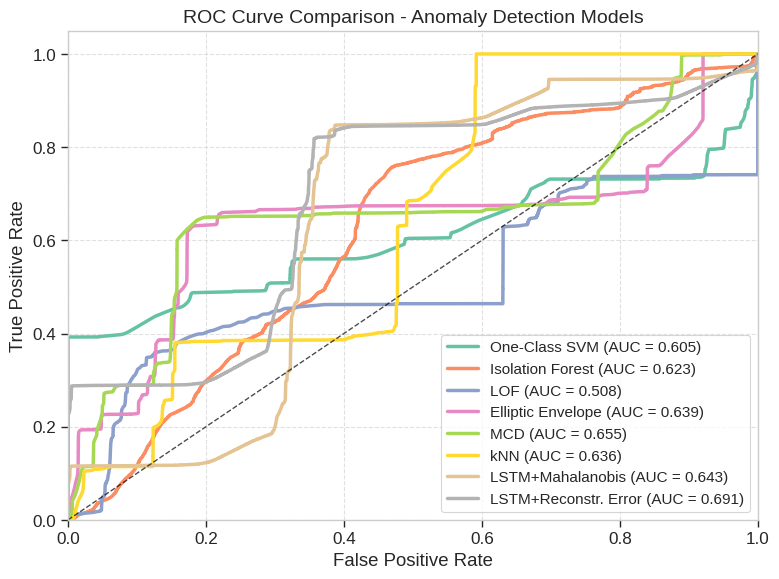

In [11]:
# Abilita stile professionale
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.4)

# Modelli e nomi leggibili
models = [
    "oneclass_withMFS", "isolationf_withMFS", "lof_withMFS", "ellipticenvelope_withMFS", "mcd_withMFS", "knn_withMFS",
    "best_lstm_mahalanobis_withMFS",
    "best_lstm_mse_global_sum_withMFS",
]
labels = [
    "One-Class SVM", "Isolation Forest", "LOF", "Elliptic Envelope", "MCD", "kNN",
     "LSTM+Mahalanobis", "LSTM+Reconstr. Error"
]
colors = sns.color_palette("Set2", n_colors=len(models))

plt.figure(figsize=(8, 6))

for model_name, label_name, color in zip(models, labels, colors):
    file_path = f"roc_data_{model_name}.txt"
    loaded = False
    for sep in ['\t', ',']:
        try:
            df = pd.read_csv(file_path, sep=sep, header=0)
            fpr, tpr = df.iloc[:, 0].values, df.iloc[:, 1].values
            roc_auc = auc(fpr, tpr)

            # Fix curva ROC se sotto random
            if roc_auc < 0.5:
                roc_auc = 1 - roc_auc
                fpr, tpr = tpr, fpr

            plt.plot(fpr, tpr, lw=2.5, color=color, label=f"{label_name} (AUC = {roc_auc:.3f})")
            loaded = True
            break  # Esci dal ciclo dei separatori se ha funzionato
        except Exception as e:
            continue  # Prova il prossimo separatore

    if not loaded:
        print(f"❌ Errore caricando {file_path}: formato non riconosciuto.")

# Linea random
plt.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--', alpha=0.7)

# Layout
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - Anomaly Detection Models', fontsize=14)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc="lower right", frameon=True, fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Salvataggio
plt.savefig("roc_comparison_withMFS.pdf", format='pdf', dpi=300)
plt.show()